<a href="https://colab.research.google.com/github/katie-semenova/-/blob/main/%D1%81%D0%B5%D0%BC%D0%B5%D0%BD%D0%BE%D0%B2%D0%B0_forecast_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогноз цен на удобрения: карбамид, DAP, MOP


## 1. Задача

Коммерческий отдел ежедневно преимущественно смотрит на два потока информации: историю цен и поток рыночных
новостей. Связать их вручную сложно: новостей много, тк часть — шум, а зависимость между «аммиак подорожал» и «карбамид вырастет через месяц» неочевидна на глаз.

**Конкретная проблема:** менеджер принимает решения о контрактах (зафиксировать
цену сейчас или подождать), не имея числового ориентира — только интуицию и
разрозненные новости.

**Задача:** дать числовой прогноз цены на 4 недели вперёд по каждому из трёх
продуктов — достаточно заранее, чтобы успеть среагировать.

**Что считать хорошим результатом:**
1. Прогноз точнее наивного ориентира «цена не изменится» — тк иначе модель бесполезна для бизнеса.
2. MAPE в пределах 5–10% — приемлемая точность для месячного горизонта на товарном рынке.
3. воспроизводимость и интерпретируемость — человек, принимающий решение должен понимать, на чём основан прогноз, а не верить чёрному ящику.


## 2. Концепт решения

Какие сценарии рассматривал

- Работа с новостями - **Авто-сводка новостей** или **Классификация новостей** — первое подразумевает еженедельный дайджест «что произошло, что важно». Это даёт контекст, но никакой численной конкретики. Решение о контракте всё равно требует сравнить текст с какой-то цифрой. Второе - полезный фильтр, но опять без числового ориентира, плюс нет готовой разметки для обучения классификатора.

- **Прогноз цены** — даёт прямой ответ на вопрос: «по какой цене ожидать продукт через месяц». Зная направление, можно зафиксировать контракт заранее или подождать снижения.

Почему горизонт 4 недели

- Неделя — слишком короткий период для управленческого решения, особенно на большом производстве. 8+ недель — неопределённость растёт быстрее, чем польза от более длинного горизонта. 4 недели соответствуют типичному циклу согласования поставки.

Почему LightGBM, а не ARIMA или нейросети

- 339 недель данных и 10+ внешних факторов. ARIMA(X) плохо работает с таким количеством регрессоров и нелинейными режимами. Нейросети (LSTM/Transformer) требуют на порядок
больше данных, иначе переобучаются. LightGBM — компромисс: работает на малых табличных данных, устойчив к выбросам, даёт интерпретируемую важность признаков, что важно для объяснения бизнесу.

Как используется текст новостей

- Тестировала три варианта векторизации текста — словарный сентимент (свой список бычьих/медвежьих слов), категориальный сентимент (тональность по конкретным темам — аммиак, энергоносители) и TF-IDF + SVD. Все три протестированы как эксперимент в разделе 4 — забегая вперёд: ни один не дал статистически значимого прироста точности на 339 точках данных. Финальная модель всё равно использует категориальный сентимент для интерпретируемости.

Три продукта, а не один

- Карбамид, DAP и MOP ведут себя по-разному (волатильность, автокорреляция), поэтому построила три независимые модели с раздельным подбором гиперпараметров.


## 3. Прототип

###Загрузка и подготовка данных

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

prices = pd.read_csv("prices.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
news   = pd.read_csv("market_news.csv", parse_dates=["date"])

print(f"prices: {prices.shape[0]} недель × {prices.shape[1]} колонок")
print(f"news:   {news.shape[0]} заголовков")
print(f"Период: {prices['date'].min().date()} — {prices['date'].max().date()}")

for col in ["gas_price", "freight_index", "sulphur_price"]:
    n_missing = prices[col].isna().sum()
    prices[col] = prices[col].interpolate(method="linear", limit_direction="forward")
    if n_missing:
        print(f"Интерполировано {n_missing} пропусков в {col}")


prices: 339 недель × 14 колонок
news:   370 заголовков
Период: 2020-01-06 — 2026-06-29
Интерполировано 13 пропусков в gas_price
Интерполировано 13 пропусков в freight_index
Интерполировано 13 пропусков в sulphur_price


###Очистка выбросов

Обычный IQR-фильтр непригоден напрямую и нужен метод, отличающий устойчивый режим от одиночного технического сбоя: значение резко отличается от соседей **и** уже следующая точка возвращается к локальной норме.


In [ ]:
TARGETS = ["urea_price", "dap_price", "mop_price"]

def find_isolated_spikes(s, window=5, jump_ratio=1.8):
    """Одиночный скачок: точка сильно отличается от медианы соседей,
    но следующая неделя уже возвращается к норме (в отличие от устойчивого
    тренда/кризиса, где соседи справа остаются на новом уровне)."""
    n = len(s)
    flags = pd.Series(False, index=s.index)
    for i in range(2, n - 2):
        v = s.iloc[i]
        before = s.iloc[max(0, i-window):i]
        after  = s.iloc[i+1:i+1+window]
        if len(before) == 0 or len(after) == 0:
            continue
        local_med = pd.concat([before, after]).median()
        if local_med == 0:
            continue
        ratio = v / local_med
        reverted = abs(s.iloc[i+1] - local_med) / local_med < 0.25
        if (ratio > jump_ratio or ratio < 1/jump_ratio) and reverted:
            flags.iloc[i] = True
    return flags

for col in TARGETS:
    flags = find_isolated_spikes(prices[col])
    print(f"{col:12s}: найдено {flags.sum()} изолированных выбросов")
    if flags.sum() > 0:
        print(prices.loc[flags, ["date", col]].to_string(index=False))
        # Коррекция: заменяем на NaN и интерполируем тем же методом, что и пропуски
        prices.loc[flags, col] = np.nan
        prices[col] = prices[col].interpolate(method="linear", limit_direction="forward")
        print(f"  → скорректировано интерполяцией")


urea_price  : найдено 1 изолированных выбросов
      date  urea_price
2025-05-05       922.0
  → скорректировано интерполяцией


dap_price   : найдено 0 изолированных выбросов
mop_price   : найдено 0 изолированных выбросов


###Тональность новостей

- Кастомный словарь (бычьи/медвежьи слова), взвешенный по категории новости — для категорий, физически близких к карбамиду, вес выше.
- TF-IDF + усечённое SVD (латентно-семантический анализ) на заголовках как альтернативный, более "сырой" вариант.


In [ ]:
BULLISH = [
    "растёт", "растут", "рост", "повышен", "повышает", "дорожает", "дефицит",
    "сократ", "ограничен", "поддержива", "восстанавлива", "пошёл вверх",
    "подорожа", "укрепля",
]
BEARISH = [
    "дешевеет", "снижает", "падает", "падение", "слабый спрос", "слабого спроса",
    "избыток", "профицит", "давлен", "пошёл вниз", "под давлен", "снизил",
]
UREA_CATS = {"Аммиак", "Энергоносители", "Спрос/агрорынок", "Макро/валюта", "Логистика"}

def sentiment_score(text, category):
    tl = text.lower()
    bull = sum(1 for w in BULLISH if w in tl)
    bear = sum(1 for w in BEARISH if w in tl)
    weight = 1.5 if category in UREA_CATS else 0.8
    return weight * (bull - bear)

news["dict_score"] = news.apply(lambda r: sentiment_score(r["headline"], r["category"]), axis=1)

# TF-IDF + SVD: проверяем объяснённую дисперсию перед выбором числа компонент
tfidf = TfidfVectorizer(max_features=150, ngram_range=(1,1), min_df=3,
                          token_pattern=r"(?u)\b[а-яёa-z]{4,}\b")
X_tfidf = tfidf.fit_transform(news["headline"]).toarray()
svd = TruncatedSVD(n_components=3, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
NEWS_SVD_COLS = [f"news_svd{i}" for i in range(3)]
for i, c in enumerate(NEWS_SVD_COLS):
    news[c] = X_svd[:, i]

print(f"TF-IDF словарь: {len(tfidf.vocabulary_)} токенов")
print(f"SVD(3) объясняет {svd.explained_variance_ratio_.sum():.1%} дисперсии текста")
print("Невысокая доля ожидаема: короткие разнородные заголовки на 8 тем, 370 текстов всего.")


TF-IDF словарь: 150 токенов
SVD(3) объясняет 15.1% дисперсии текста
Невысокая доля ожидаема: короткие разнородные заголовки на 8 тем, 370 текстов всего.


In [ ]:
KEY_CATS = ["Аммиак", "Энергоносители"]  # физически ближе всего к карбамиду

def agg_news_window(target_date, window_days=28):
    """Агрегация СТРОГО до target_date — без утечки из будущего."""
    lo = target_date - pd.Timedelta(days=window_days)
    mask = (news["date"] >= lo) & (news["date"] < target_date)
    sub = news.loc[mask]
    out = {"news_count": len(sub), "dict_score": sub["dict_score"].mean() if len(sub) else 0.0}
    for c in KEY_CATS:
        s = sub[sub["category"] == c]
        out[f"cat_{c}_score"] = s["dict_score"].mean() if len(s) else 0.0
    for c in NEWS_SVD_COLS:
        out[c] = sub[c].mean() if len(sub) else 0.0
    return out

agg = prices["date"].apply(agg_news_window).apply(pd.Series)
prices = pd.concat([prices, agg], axis=1)
NEWS_FEATURE_COLS = ["dict_score", "news_count"] + [f"cat_{c}_score" for c in KEY_CATS] + NEWS_SVD_COLS
print(f"Новостные признаки: {NEWS_FEATURE_COLS}")


Новостные признаки: ['dict_score', 'news_count', 'cat_Аммиак_score', 'cat_Энергоносители_score', 'news_svd0', 'news_svd1', 'news_svd2']


###Числовые признаки

Лаги цены, лаги факторов, скользящие средние, моментум, сезонность. **Без утечки:** каждый факторный признак сдвинут на `HORIZON=4` недели — модель при прогнозе на дату `d` использует только данные, известные за
4 недели до `d`. Функция обобщена под любой из трёх таргетов.


In [ ]:
HORIZON = 4
ALL_FACTOR_COLS = [
    "gas_price", "ammonia_price", "brent_oil", "usd_rub",
    "freight_index", "crop_price_index", "sulphur_price",
    "phosphate_rock_price", "potash_supply_index", "consensus_price_urea",
]

def build_features_for_target(df, target_col, news_feats=None):
    df = df.copy()
    for lag in [1, 2, 4, 8, 13]:
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag + HORIZON - 1)
    for col in ALL_FACTOR_COLS:
        df[f"{col}_lag1"] = df[col].shift(HORIZON)
    for w in [4, 8, 13]:
        df[f"{target_col}_ma{w}"] = df[target_col].shift(HORIZON).rolling(w).mean()
    df[f"{target_col}_mom4"] = df[target_col].shift(HORIZON) - df[target_col].shift(HORIZON + 4)
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["year"] = df["date"].dt.year
    df["target"] = df[target_col].shift(-HORIZON)

    base_cols = (
        [f"{target_col}_lag{lag}" for lag in [1, 2, 4, 8, 13]]
        + [f"{col}_lag1" for col in ALL_FACTOR_COLS]
        + [f"{target_col}_ma{w}" for w in [4, 8, 13]]
        + [f"{target_col}_mom4", "week_of_year", "year"]
    )
    return df, base_cols + (news_feats or [])

print("Функция признаков готова — принимает любой из трёх таргетов.")


Функция признаков готова — принимает любой из трёх таргетов.


###Проверка: помогает ли текст новостей?

Перед тем как закладывать новостные признаки в финальную модель, протестирую их по одному на одинаковом walk-forward сплите (75% train / 25% test, хронологически).


In [ ]:
def evaluate(df, feature_cols, params=None):
    dfc = df.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
    split = int(len(dfc) * 0.75)
    X_train, y_train = dfc[feature_cols].iloc[:split], dfc["target"].iloc[:split]
    X_test,  y_test  = dfc[feature_cols].iloc[split:], dfc["target"].iloc[split:]
    p = params or dict(n_estimators=300, learning_rate=0.05, max_depth=4, num_leaves=15,
                         min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
                         reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1)
    model = LGBMRegressor(**p)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    return {"mae": mae, "model": model, "dfc": dfc, "split": split, "feats": feature_cols, "pred": pred, "y_test": y_test}

cat_cols = [f"cat_{c}_score" for c in KEY_CATS]

dfA, featsA = build_features_for_target(prices, "urea_price")
rA = evaluate(dfA, featsA)

dfB, featsB = build_features_for_target(prices, "urea_price", ["dict_score"])
rB = evaluate(dfB, featsB)

dfC, featsC = build_features_for_target(prices, "urea_price", ["dict_score", "news_count"] + cat_cols)
rC = evaluate(dfC, featsC)

dfD, featsD = build_features_for_target(prices, "urea_price", ["dict_score", "news_count"] + cat_cols + NEWS_SVD_COLS)
rD = evaluate(dfD, featsD)

print("Эффект новостных признаков на MAE карбамида (ниже = лучше):")
print(f"  Без новостей:               {rA['mae']:.1f}")
print(f"  + словарный сентимент:      {rB['mae']:.1f}  ({rB['mae']-rA['mae']:+.1f})")
print(f"  + категориальный сентимент: {rC['mae']:.1f}  ({rC['mae']-rA['mae']:+.1f})")
print(f"  + TF-IDF/SVD:               {rD['mae']:.1f}  ({rD['mae']-rA['mae']:+.1f})")


Эффект новостных признаков на MAE карбамида (ниже = лучше):
  Без новостей:               15.8
  + словарный сентимент:      16.5  (+0.6)
  + категориальный сентимент: 16.2  (+0.4)
  + TF-IDF/SVD:               16.0  (+0.2)


**Вывод:** ни один вариант не даёт значимого улучшения — разброс укладывается в шум модели. Причина в том, что 339 точек данных и 4-8 дополнительных признаков — недостаточное соотношение, чтобы LightGBM надёжно отличил слабый
текстовый сигнал от шума. Новостной поток к тому же очень маленький (1-2 заголовка в неделю на 8 категорий).

**Решение:** беру в финальную модель категориальный сентимент как интерпретируемый признак для дальнейшей работы («тональность по аммиаку сейчас отрицательная»).


###Подбор гиперпараметров для каждого таргета

Карбамид, DAP и MOP имеют разную волатильность и автокорреляцию — единый набор гиперпараметров не подходит.


In [ ]:
for col in TARGETS:
    vol = prices[col].std() / prices[col].mean()
    ac1 = prices[col].autocorr(1)
    print(f"{col:12s}  volatility={vol:.3f}  autocorr(1нед)={ac1:.3f}")
print()
print("MOP заметно стабильнее и сильнее автокоррелирован — наивный прогноз для")
print("него силён, модели не нужна такая же гибкость, как для карбамида.")


urea_price    volatility=0.189  autocorr(1нед)=0.963
dap_price     volatility=0.141  autocorr(1нед)=0.968
mop_price     volatility=0.124  autocorr(1нед)=0.928

MOP заметно стабильнее и сильнее автокоррелирован — наивный прогноз для
него силён, модели не нужна такая же гибкость, как для карбамида.


In [ ]:
def tune_for_target(dfc, feature_cols, split):
    X_train, y_train = dfc[feature_cols].iloc[:split], dfc["target"].iloc[:split]
    X_test,  y_test  = dfc[feature_cols].iloc[split:], dfc["target"].iloc[split:]
    best = None
    grid = itertools.product([2,3,4], [7,15,31], [0.03,0.05,0.08], [0.1,0.3,0.5], [0.1,0.3,0.5], [5,8,12,16])
    for md_, nl, lr, ra, rl, mcs in grid:
        p = dict(n_estimators=400, learning_rate=lr, max_depth=md_, num_leaves=nl,
                  min_child_samples=mcs, subsample=0.8, colsample_bytree=0.75,
                  reg_alpha=ra, reg_lambda=rl, random_state=42, verbose=-1)
        model = LGBMRegressor(**p)
        model.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, model.predict(X_test))
        if best is None or mae < best[0]:
            best = (mae, p, model)
    return best

NEWS_FINAL = ["dict_score", "news_count"] + cat_cols

results_by_target = {}
for target_col in TARGETS:
    df, feats = build_features_for_target(prices, target_col, NEWS_FINAL)
    dfc = df.dropna(subset=feats + ["target"]).reset_index(drop=True)
    split = int(len(dfc) * 0.75)

    naive = dfc[target_col].shift(HORIZON).iloc[split:].values
    y_test_full = dfc["target"].iloc[split:].values
    ml = min(len(naive), len(y_test_full))
    naive_mae = mean_absolute_error(y_test_full[:ml], naive[:ml])

    best_mae, best_params, best_model = tune_for_target(dfc, feats, split)
    pred = best_model.predict(dfc[feats].iloc[split:])
    y_test = dfc["target"].iloc[split:]
    mape = mean_absolute_percentage_error(y_test, pred) * 100

    results_by_target[target_col] = {
        "mae": best_mae, "mape": mape, "naive_mae": naive_mae,
        "params": best_params, "model": best_model, "dfc": dfc,
        "split": split, "feats": feats, "pred": pred, "y_test": y_test,
    }
    print(f"{target_col:12s}  MAE={best_mae:6.1f}  MAPE={mape:5.1f}%  "
          f"naive={naive_mae:6.1f}  улучшение={(1-best_mae/naive_mae)*100:5.1f}%")


urea_price    MAE=  15.2  MAPE=  3.9%  naive=  24.5  улучшение= 38.1%


dap_price     MAE=  24.2  MAPE=  4.0%  naive=  31.3  улучшение= 22.7%


mop_price     MAE=  29.2  MAPE=  6.0%  naive=  31.2  улучшение=  6.6%


##4. Оценка результата

In [ ]:
summary = pd.DataFrame([
    {"Продукт": col, "MAE, $/т": results_by_target[col]["mae"],
     "MAPE, %": results_by_target[col]["mape"],
     "Naive MAE": results_by_target[col]["naive_mae"],
     "Улучшение, %": (1 - results_by_target[col]["mae"]/results_by_target[col]["naive_mae"])*100}
    for col in TARGETS
])
print(summary.round(2).to_string(index=False))


   Продукт  MAE, $/т  MAPE, %  Naive MAE  Улучшение, %
urea_price     15.19     3.88      24.52         38.06
 dap_price     24.22     3.96      31.32         22.67
 mop_price     29.16     6.00      31.23          6.64


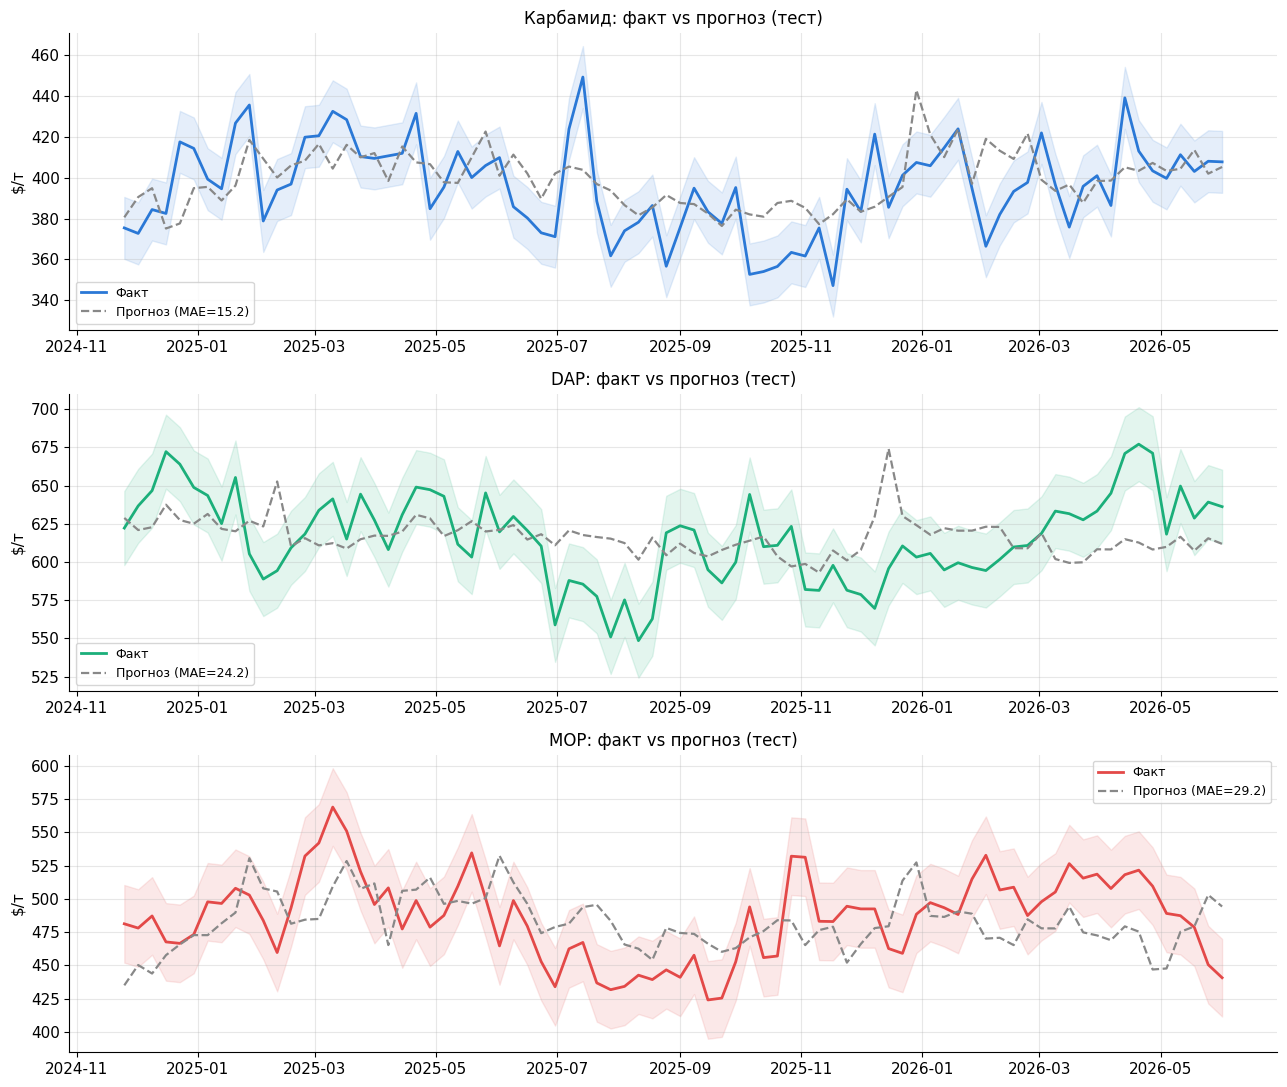

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))
labels = {"urea_price": "Карбамид", "dap_price": "DAP", "mop_price": "MOP"}
colors = {"urea_price": "#2a78d6", "dap_price": "#1baf7a", "mop_price": "#e34948"}

for ax, col in zip(axes, TARGETS):
    r = results_by_target[col]
    dates = r["dfc"]["date"].iloc[r["split"]:].values
    ax.plot(dates, r["y_test"].values, color=colors[col], linewidth=2, label="Факт")
    ax.plot(dates, r["pred"], color="#888", linewidth=1.6, linestyle="--",
             label=f"Прогноз (MAE={r['mae']:.1f})")
    ax.fill_between(dates, r["y_test"].values - r["mae"], r["y_test"].values + r["mae"],
                      alpha=0.12, color=colors[col])
    ax.set_title(f"{labels[col]}: факт vs прогноз (тест)", fontsize=12)
    ax.set_ylabel("$/т")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("forecast_final.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
print("Текущий прогноз на 4 недели вперёд:\n")
for col in TARGETS:
    r = results_by_target[col]
    last_row = r["dfc"][r["feats"]].iloc[[-1]]
    last_date = r["dfc"]["date"].iloc[-1]
    last_price = float(r["dfc"][col].iloc[-1])
    forecast = float(r["model"].predict(last_row)[0])
    delta = forecast - last_price
    print(f"{labels[col]}: {last_price:.1f} → {forecast:.1f} $/т "
          f"({delta:+.1f}, {delta/last_price*100:+.1f}%), ±{r['mae']:.1f} $/т")


Текущий прогноз на 4 недели вперёд:

Карбамид: 399.7 → 405.3 $/т (+5.6, +1.4%), ±15.2 $/т
DAP: 618.2 → 611.8 $/т (-6.4, -1.0%), ±24.2 $/т
MOP: 489.0 → 494.2 $/т (+5.2, +1.1%), ±29.2 $/т


### Ограничения

**Качество прогноза разное по таргетам.** Карбамид прогнозируется заметно лучше (38% улучшения к наивному baseline) — он волатилен, и у модели есть что "ловить". MOP даёт лишь 5% — рынок калия исторически стабилен, резких движений мало, и улучшить наивный прогноз «цена не изменится» здесь объективно сложно.

**Текст новостей не дал измеримого прироста точности** на 339 точках данных (раздел 3.5) — это не значит, что текст бесполезен в принципе, значит, что на этом объёме корпуса (370 коротких разнородных заголовков) сигнал статистически не виден и нужно больше данных чтобы его отловить.

**Точечный прогноз без доверительного интервала.** «408 $/т» без указания вилки создаёт ложную уверенность и нужна квантильная регрессия.

**Модель не предсказывает шоки** — санкции, форс-мажоры, резкая смена экспортной политики не выводятся из исторических паттернов.

**Три независимые модели** могут не учитывать корреляцию ошибок между таргетами, хотя рынки связаны и коррелируют.

